<center>

# Fairness and Bias Analysis in Machine Learning

</center>

## Import Libraries and Load Data

In [1]:
# import all necessary python libraries for data manipulation, statistical testing, and visualization.
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

# load the provided dataset.
df = pd.read_csv('data.csv')

# display basic info about the dataset.
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (2222, 16)

Column names: ['Filename', 'Image #', 'Gender', 'Race', 'Confident', 'Egotistic', 'Intelligent', 'Kind', 'Responsible', 'Trustworthy', 'Aggressive', 'Caring', 'Emotional', 'Friendly', 'Sociable', 'Qualified']

First 5 rows:


,Filename,Image #,Gender,Race,Confident,Egotistic,Intelligent,Kind,Responsible,Trustworthy,Aggressive,Caring,Emotional,Friendly,Sociable,Qualified
0,Google_1_Danielle Goble_5_oval.jpg,1,1,1,5.67,3.67,5.60,5.00,5.80,5.33,4.80,4.67,3.67,4.33,4.67,0
1,Google_1_Phillip Owensby_9_oval.jpg,2,0,1,6.53,2.20,6.60,7.00,7.47,6.73,3.13,6.93,5.80,6.73,6.60,1
2,Google_1_Douglas Ziegler_3_oval.jpg,3,1,1,6.07,3.60,6.47,6.47,6.67,6.40,2.40,6.07,5.14,6.67,6.67,0
3,Google_1_Donald Sauls_11_oval.jpg,4,1,2,4.80,4.60,4.47,3.80,4.27,3.87,5.80,3.53,2.80,2.93,3.27,0
4,Google_1_Eric Harman_5_oval.jpg,5,1,6,6.67,5.40,6.33,4.87,5.87,4.67,4.27,4.07,4.80,5.20,5.33,1


## Data Overview and Preprocessing

We will first inspect the dataset structure, the distribution of demographic groups, and the psychological trait columns before conducting the bias analysis. 

According to the README file, the demographic encodings are:

**Gender:** 0 = Female, 1 = Male

**Race:** 0 = Other, 1 = White, 2 = Black, 3 = East Asian, 4 = South Asian, 5 = Hispanic, 6 = Middle Eastern

NOTE: For this assignment, we will focus on **White, Black, East Asian** for race.

In [2]:
# define psychological traits:
traits = ['Confident', 'Egotistic', 'Intelligent', 'Kind', 'Responsible',
          'Trustworthy', 'Aggressive', 'Caring', 'Emotional', 'Friendly', 'Sociable']

# define gender mappings:
gender_map = {0: 'Female', 1: 'Male'}

# define demographic mappings:
race_map = {0: 'Other', 1: 'White', 2: 'Black', 3: 'East Asian',
            4: 'South Asian', 5: 'Hispanic', 6: 'Middle Eastern'}

# Display demographic distributions
print("=" * 80)
print("Gender Distribution")
print("=" * 80)
gender_counts = df['Gender'].value_counts().sort_index()
for code_val, count in gender_counts.items():
    print(f"  {gender_map.get(code_val, code_val)}: {count} ({count/len(df)*100:.1f}%)")

print(f"\n{'=' * 80}")
print("Race Distribution")
print("=" * 80)
race_counts = df['Race'].value_counts().sort_index()
for code_val, count in race_counts.items():
    print(f"  {race_map.get(code_val, code_val)}: {count} ({count/len(df)*100:.1f}%)")

print(f"\n{'=' * 80}")
print("Psychological Trait Summary Statistics")
print("=" * 80)
df[traits].describe().round(3)

Gender Distribution
  Female: 953 (42.9%)
  Male: 1269 (57.1%)

Race Distribution
  Other: 2 (0.1%)
  White: 1836 (82.6%)
  Black: 220 (9.9%)
  East Asian: 63 (2.8%)
  South Asian: 5 (0.2%)
  Hispanic: 72 (3.2%)
  Middle Eastern: 24 (1.1%)

Psychological Trait Summary Statistics


,Confident,Egotistic,Intelligent,Kind,Responsible,Trustworthy,Aggressive,Caring,Emotional,Friendly,Sociable
count,2222.000,2222.000,2222.000,2222.000,2222.000,2222.000,2222.000,2222.000,2222.000,2222.000,2222.000
mean,5.921,4.076,5.836,5.677,5.861,5.609,3.689,5.543,4.855,5.821,5.818
std,0.821,0.947,0.741,1.087,0.878,0.936,1.131,1.064,0.704,1.230,1.111
min,2.400,1.800,2.930,1.670,2.400,2.200,1.400,2.130,2.400,2.000,2.130
25%,5.430,3.400,5.470,5.070,5.470,5.070,2.870,4.930,4.385,5.130,5.200
50%,6.070,4.000,5.930,5.930,6.065,5.800,3.470,5.800,4.870,6.130,6.070
75%,6.500,4.685,6.330,6.470,6.470,6.290,4.330,6.330,5.400,6.730,6.600
max,7.800,7.130,7.500,7.940,7.530,7.440,7.530,7.730,7.000,8.130,8.200


In [3]:
# filter dataset for the three racial groups of interest: White, Black, East Asian.
race_df = df[df['Race'].isin([1, 2, 3])].copy()
race_df['Race_Label'] = race_df['Race'].map(race_map)

print(f"Filtered dataset for race analysis: {len(race_df)} samples")
print(f"  White:      {len(race_df[race_df['Race'] == 1])} samples")
print(f"  Black:      {len(race_df[race_df['Race'] == 2])} samples")
print(f"  East Asian: {len(race_df[race_df['Race'] == 3])} samples")

# add gender labels for later use
df['Gender_Label'] = df['Gender'].map(gender_map)

Filtered dataset for race analysis: 2119 samples
  White:      1836 samples
  Black:      220 samples
  East Asian: 63 samples


## Race Bias Analysis

In this section, we will investigate whether the perceived race influences annotators' trait ratings. We will compare the mean trait scores across three racial groups (White, Black, and East Asian) using one-way ANOVA tests to determine whether statistically significant differences exist.

**Procedure:**
- For each of the 11 psychological traits, conduct a one-way ANOVA test across the three race groups.
- A p-value < 0.05 indicates that at least one group's mean is significantly different from the others.
- Also compute the mean and median trait scores per race group for interpretability.

In [ ]:
# =====================================================================
# One-Way ANOVA test for race across all psychological traits
# =====================================================================

# separate the trait data by race group
white = race_df[race_df['Race'] == 1]
black = race_df[race_df['Race'] == 2]
east_asian = race_df[race_df['Race'] == 3]

# store ANOVA results in a structured format
race_anova_results = []

print("=" * 100)
print(f"{'Trait':<15} {'F-statistic':>12} {'p-value':>14} {'White Mean':>12} {'Black Mean':>12} {'E.Asian Mean':>14} {'Significant?':>14}")
print("=" * 100)

for trait in traits:
    # extract trait values for each race group
    group_w = white[trait].dropna()
    group_b = black[trait].dropna()
    group_ea = east_asian[trait].dropna()

    # perform one-way ANOVA test
    f_stat, p_val = stats.f_oneway(group_w, group_b, group_ea)

    # compute group means and medians
    mean_w, mean_b, mean_ea = group_w.mean(), group_b.mean(), group_ea.mean()
    med_w, med_b, med_ea = group_w.median(), group_b.median(), group_ea.median()

    # determine significance at alpha = 0.05
    sig = "Yes ***" if p_val < 0.001 else ("Yes **" if p_val < 0.01 else ("Yes *" if p_val < 0.05 else "No"))

    race_anova_results.append({
        'Trait': trait, 'F-statistic': f_stat, 'p-value': p_val,
        'White Mean': mean_w, 'Black Mean': mean_b, 'East Asian Mean': mean_ea,
        'White Median': med_w, 'Black Median': med_b, 'East Asian Median': med_ea,
        'Significant': p_val < 0.05, 'Category': 'Race'
    })

    print(f"{trait:<15} {f_stat:>12.4f} {p_val:>14.2e} {mean_w:>12.3f} {mean_b:>12.3f} {mean_ea:>14.3f} {sig:>14}")

print("=" * 100)
print("\nNOTE: *** for p < 0.001, ** for p < 0.01, and * for p < 0.05 (Significance levels)")

# convert to DataFrame for easier manipulation
race_results_df = pd.DataFrame(race_anova_results)

Trait            F-statistic        p-value   White Mean   Black Mean   E.Asian Mean   Significant?
Confident             0.6685       5.13e-01        5.925        5.968          5.836             No
Egotistic            15.8705       1.44e-07        4.057        4.323          3.604        Yes ***
Intelligent          34.5783       1.67e-15        5.864        5.529          6.318        Yes ***
Kind                  8.9954       1.29e-04        5.715        5.404          5.857        Yes ***
Responsible          23.5057       8.01e-11        5.905        5.514          6.146        Yes ***
Trustworthy          12.5889       3.67e-06        5.645        5.347          5.867        Yes ***
Aggressive           24.6142       2.71e-11        3.637        4.128          3.218        Yes ***
Caring                7.8064       4.19e-04        5.580        5.305          5.751        Yes ***
Emotional             3.7705       2.32e-02        4.870        4.732          4.845          Yes *


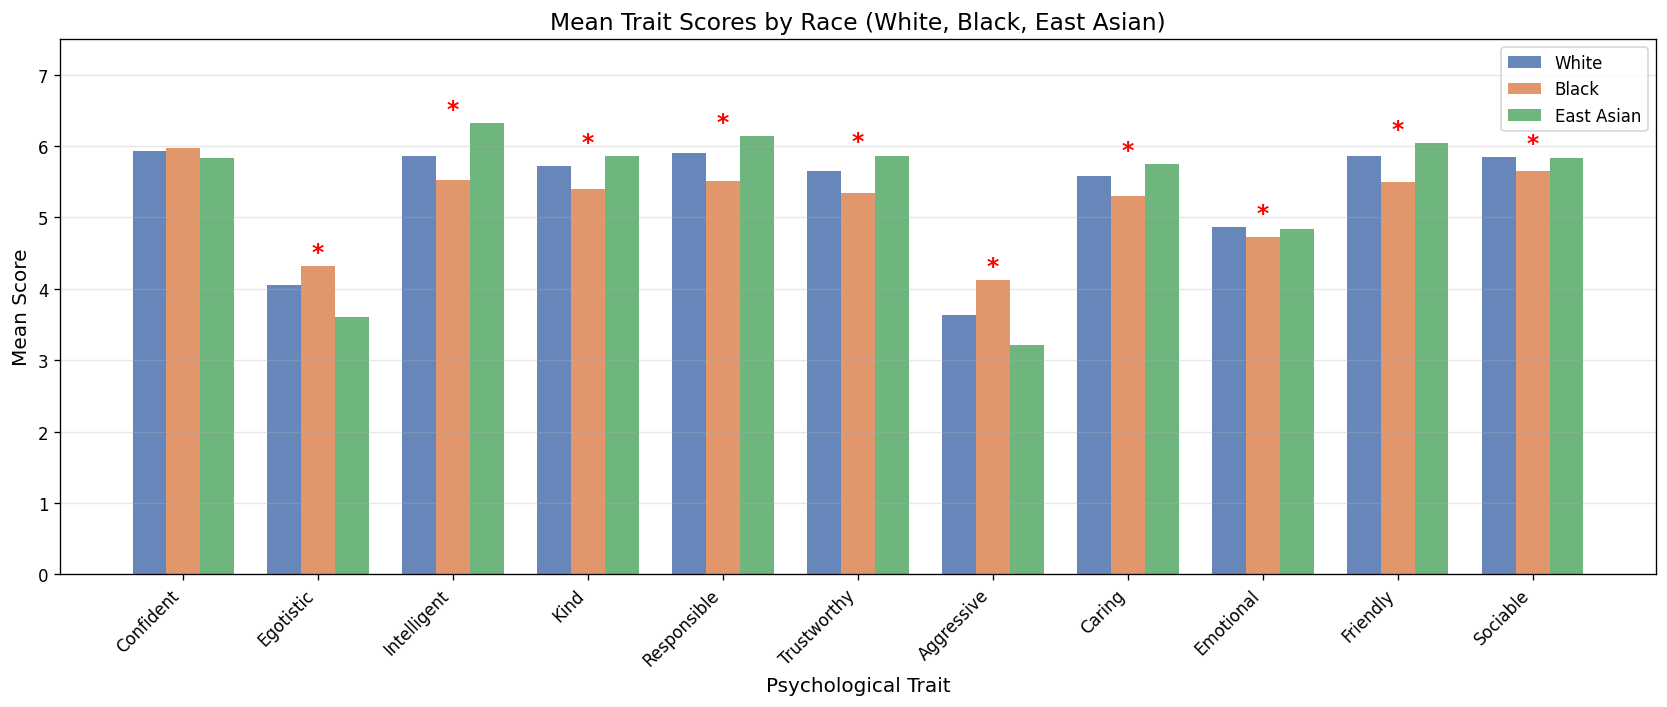

In [7]:
# Visualize race-wise mean trait scores with a grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(traits))
width = 0.25

# Plot bars for each race group
bars_w = ax.bar(x - width, race_results_df['White Mean'], width, label='White', color='#4C72B0', alpha=0.85)
bars_b = ax.bar(x, race_results_df['Black Mean'], width, label='Black', color='#DD8452', alpha=0.85)
bars_ea = ax.bar(x + width, race_results_df['East Asian Mean'], width, label='East Asian', color='#55A868', alpha=0.85)

# Add significance markers for traits with p < 0.05 in red.
for i, row in race_results_df.iterrows():
    if row['Significant']:
        max_val = max(row['White Mean'], row['Black Mean'], row['East Asian Mean'])
        ax.annotate('*', xy=(i, max_val + 0.1), ha='center', fontsize=14, fontweight='bold', color='red')

ax.set_xlabel('Psychological Trait', fontsize=12)
ax.set_ylabel('Mean Score', fontsize=12)
ax.set_title('Mean Trait Scores by Race (White, Black, East Asian)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(traits, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 7.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Detailed mean and median comparison table by race
print("=" * 80)
print("Detailed Mean and Median Trait Scores by Race")
print("=" * 80)
print(f"{'Trait':<15} {'White':^20} {'Black':^20} {'East Asian':^20}")
print(f"{'':15} {'Mean':>8} {'Median':>10} {'Mean':>8} {'Median':>10} {'Mean':>8} {'Median':>10}")
print("-" * 80)

for _, row in race_results_df.iterrows():
    print(f"{row['Trait']:<15} {row['White Mean']:>8.3f} {row['White Median']:>10.3f} "
          f"{row['Black Mean']:>8.3f} {row['Black Median']:>10.3f} "
          f"{row['East Asian Mean']:>8.3f} {row['East Asian Median']:>10.3f}")

Detailed Mean and Median Trait Scores by Race
Trait                  White                Black              East Asian     
                    Mean     Median     Mean     Median     Mean     Median
--------------------------------------------------------------------------------
Confident          5.925      6.030    5.968      6.130    5.836      5.870
Egotistic          4.057      4.000    4.323      4.200    3.604      3.330
Intelligent        5.864      6.000    5.529      5.700    6.318      6.470
Kind               5.715      5.930    5.404      5.835    5.857      6.190
Responsible        5.905      6.070    5.514      5.800    6.146      6.270
Trustworthy        5.645      5.800    5.347      5.670    5.867      6.000
Aggressive         3.637      3.400    4.128      3.730    3.218      2.930
Caring             5.580      5.800    5.305      5.730    5.751      6.000
Emotional          4.870      4.870    4.732      4.730    4.845      4.930
Friendly           5.868      6.19

## Gender Bias Analysis

In this section, we investigate whether the perceived gender influences annotators' trait ratings. We compare the mean trait scores between Female and Male groups using independent samples t-tests.

**Procedure:**
- For each of the 11 psychological traits, conduct an independent sample t-test between Female and Male groups.
- A p-value < 0.05 indicates that the means differ significantly between the two groups.
- Report the t-statistic, p-value, and group means for each trait.

In [ ]:
# =================================================================
# Independent Samples t-test for gender across all traits
# =================================================================

female = df[df['Gender'] == 0]
male = df[df['Gender'] == 1]

gender_ttest_results = []

print("=" * 100)
print(f"{'Trait':<15} {'t-statistic':>12} {'p-value':>14} {'Female Mean':>13} {'Male Mean':>11} {'Diff (F-M)':>12} {'Significant?':>14}")
print("=" * 100)

for trait in traits:
    # extract trait values for each gender group
    group_f = female[trait].dropna()
    group_m = male[trait].dropna()

    # perform independent samples t-test
    t_stat, p_val = stats.ttest_ind(group_f, group_m)

    # compute group means
    mean_f, mean_m = group_f.mean(), group_m.mean()
    med_f, med_m = group_f.median(), group_m.median()
    diff = mean_f - mean_m

    # determine significance at alpha = 0.05
    sig = "Yes ***" if p_val < 0.001 else ("Yes **" if p_val < 0.01 else ("Yes *" if p_val < 0.05 else "No"))

    gender_ttest_results.append({
        'Trait': trait, 't-statistic': t_stat, 'p-value': p_val,
        'Female Mean': mean_f, 'Male Mean': mean_m,
        'Female Median': med_f, 'Male Median': med_m,
        'Difference': diff, 'Significant': p_val < 0.05, 'Category': 'Gender'
    })

    print(f"{trait:<15} {t_stat:>12.4f} {p_val:>14.2e} {mean_f:>13.3f} {mean_m:>11.3f} {diff:>+12.3f} {sig:>14}")

print("=" * 100)
print("\nNOTE: *** for p < 0.001, ** for p < 0.01, and * for p < 0.05 (Significance levels)")

gender_results_df = pd.DataFrame(gender_ttest_results)

Trait            t-statistic        p-value   Female Mean   Male Mean   Diff (F-M)   Significant?
Confident             3.6692       2.49e-04         5.994       5.866       +0.129        Yes ***
Egotistic           -22.7263      5.72e-103         3.602       4.433       -0.831        Yes ***
Intelligent           6.2023       6.62e-10         5.948       5.752       +0.195        Yes ***
Kind                 20.2977       3.68e-84         6.173       5.304       +0.869        Yes ***
Responsible          12.3628       5.31e-34         6.118       5.668       +0.450        Yes ***
Trustworthy          18.7551       5.71e-73         6.009       5.309       +0.699        Yes ***
Aggressive          -22.4710      6.29e-101         3.128       4.111       -0.983        Yes ***
Caring               22.9659      6.75e-105         6.081       5.139       +0.942        Yes ***
Emotional            29.8302      1.03e-164         5.289       4.528       +0.761        Yes ***
Friendly            

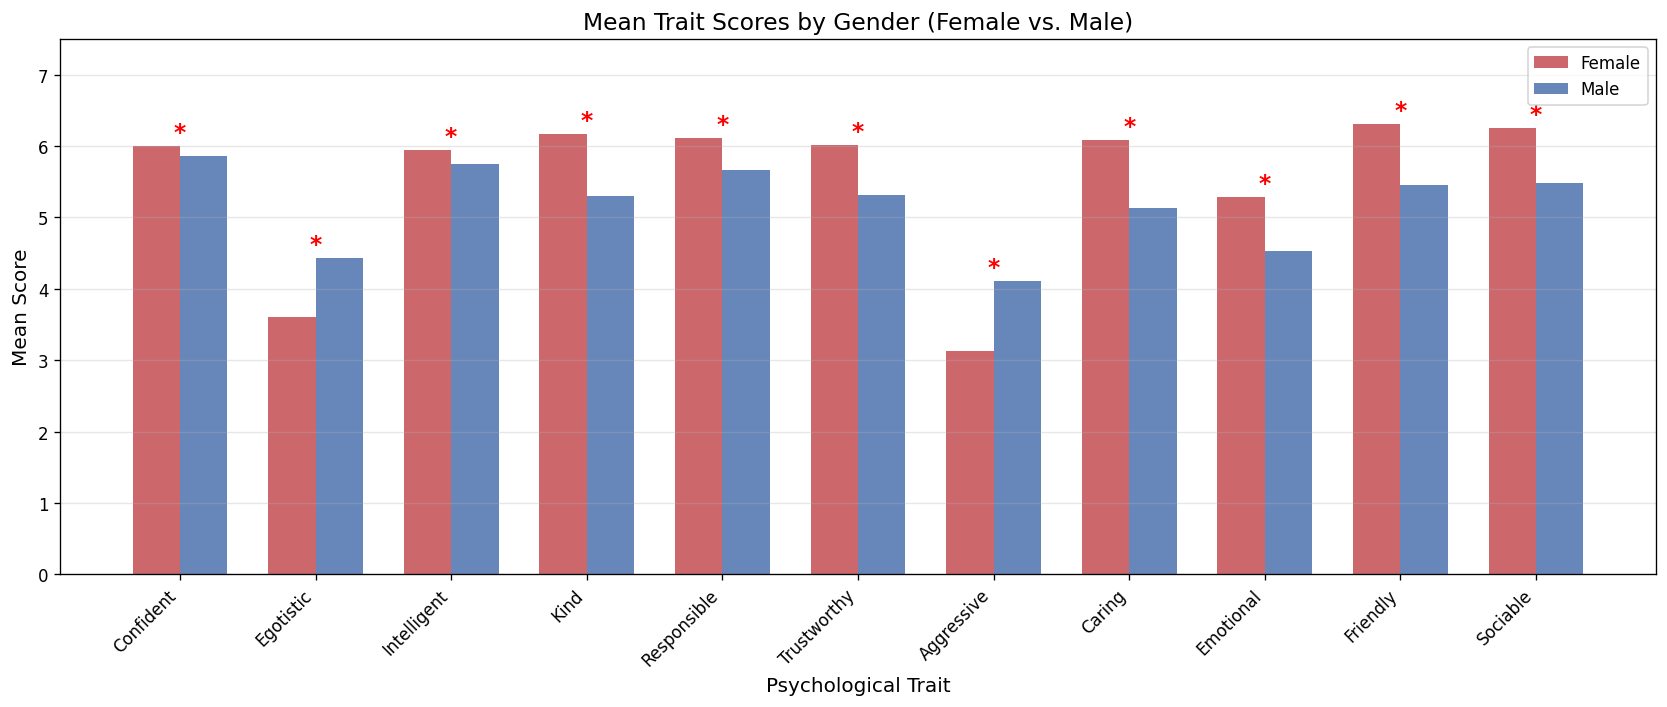

In [11]:
# Visualize gender-wise mean trait scores with a grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(traits))
width = 0.35

bars_f = ax.bar(x - width/2, gender_results_df['Female Mean'], width, label='Female', color='#C44E52', alpha=0.85)
bars_m = ax.bar(x + width/2, gender_results_df['Male Mean'], width, label='Male', color='#4C72B0', alpha=0.85)

# Add significance markers for traits with p < 0.05
for i, row in gender_results_df.iterrows():
    if row['Significant']:
        max_val = max(row['Female Mean'], row['Male Mean'])
        ax.annotate('*', xy=(i, max_val + 0.1), ha='center', fontsize=14, fontweight='bold', color='red')

ax.set_xlabel('Psychological Trait', fontsize=12)
ax.set_ylabel('Mean Score', fontsize=12)
ax.set_title('Mean Trait Scores by Gender (Female vs. Male)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(traits, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 7.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Top 5 Most Significant Biases

In this section, we combine all bias results from both race and gender analyses, rank them by statistical significance (p-value), and report the top 5 most significant biases.

In [ ]:
# ============================================================
# Combine race and gender results and rank by p-value
# ============================================================

# Build a unified list of all bias test results
all_biases = []

# Add race ANOVA results
for _, row in race_results_df.iterrows():
    all_biases.append({
        'Category': 'Race',
        'Trait': row['Trait'],
        'Test': 'One-Way ANOVA',
        'Statistic': row['F-statistic'],
        'p-value': row['p-value'],
        'Description': f"White={row['White Mean']:.3f}, Black={row['Black Mean']:.3f}, E.Asian={row['East Asian Mean']:.3f}"
    })

# Add gender t-test results
for _, row in gender_results_df.iterrows():
    all_biases.append({
        'Category': 'Gender',
        'Trait': row['Trait'],
        'Test': 'Independent t-test',
        'Statistic': row['t-statistic'],
        'p-value': row['p-value'],
        'Description': f"Female={row['Female Mean']:.3f}, Male={row['Male Mean']:.3f}"
    })

# create DataFrame and sort by p-value (ascending = most significant first)
all_biases_df = pd.DataFrame(all_biases)
all_biases_df_sorted = all_biases_df.sort_values('p-value').reset_index(drop=True)
all_biases_df_sorted.index = all_biases_df_sorted.index + 1  # Start ranking from 1

# display the full ranking
print("=" * 100)
print("Complete Bias Ranking (All Race + Gender tests, sorted by p-value)")
print("=" * 100)
print(f"{'Rank':<6} {'Category':<10} {'Trait':<15} {'Test':<20} {'Statistic':>12} {'p-value':>14}")
print("=" * 100)
for idx, row in all_biases_df_sorted.iterrows():
    print(f"{idx:<6} {row['Category']:<10} {row['Trait']:<15} {row['Test']:<20} {row['Statistic']:>12.4f} {row['p-value']:>14.2e}")

# identify the top 5
print(f"\n{'=' * 100}")
print("TOP 5 MOST SIGNIFICANT BIASES")
print(f"{'=' * 100}")
top5 = all_biases_df_sorted.head(5)
for idx, row in top5.iterrows():
    print(f"\n  Rank {idx}: {row['Category']} x {row['Trait']}")
    print(f"    Test: {row['Test']}, Statistic = {row['Statistic']:.4f}, p-value = {row['p-value']:.2e}")
    print(f"    Group Means: {row['Description']}")

Complete Bias Ranking (All Race + Gender tests, sorted by p-value)
Rank   Category   Trait           Test                    Statistic        p-value
1      Gender     Emotional       Independent t-test        29.8302      1.03e-164
2      Gender     Caring          Independent t-test        22.9659      6.75e-105
3      Gender     Egotistic       Independent t-test       -22.7263      5.72e-103
4      Gender     Aggressive      Independent t-test       -22.4710      6.29e-101
5      Gender     Kind            Independent t-test        20.2977       3.68e-84
6      Gender     Trustworthy     Independent t-test        18.7551       5.71e-73
7      Gender     Friendly        Independent t-test        17.4730       3.71e-64
8      Gender     Sociable        Independent t-test        17.1820       3.19e-62
9      Gender     Responsible     Independent t-test        12.3628       5.31e-34
10     Race       Intelligent     One-Way ANOVA             34.5783       1.67e-15
11     Race       Ag

### Top 5 Most Significant Biases

| Rank | Demographic | Trait | p-value |
|------|------------|-------|---------|
| 1 | Gender | Emotional | ≈ 1.03 × 10⁻¹⁶⁴ |
| 2 | Gender | Caring | ≈ 6.75 × 10⁻¹⁰⁵ |
| 3 | Gender | Egotistic | ≈ 5.72 × 10⁻¹⁰³ |
| 4 | Gender | Aggressive | ≈ 6.29 × 10⁻¹⁰¹ |
| 5 | Gender | Kind | ≈ 3.68 × 10⁻⁸⁴ |

## Histograms for Top 5 Most Significant Biases

We plot overlapping histograms for the top 5 most significant biases identified previously. Since all top 5 biases are gender-related, we plot the distribution of each trait for Female vs. Male groups.

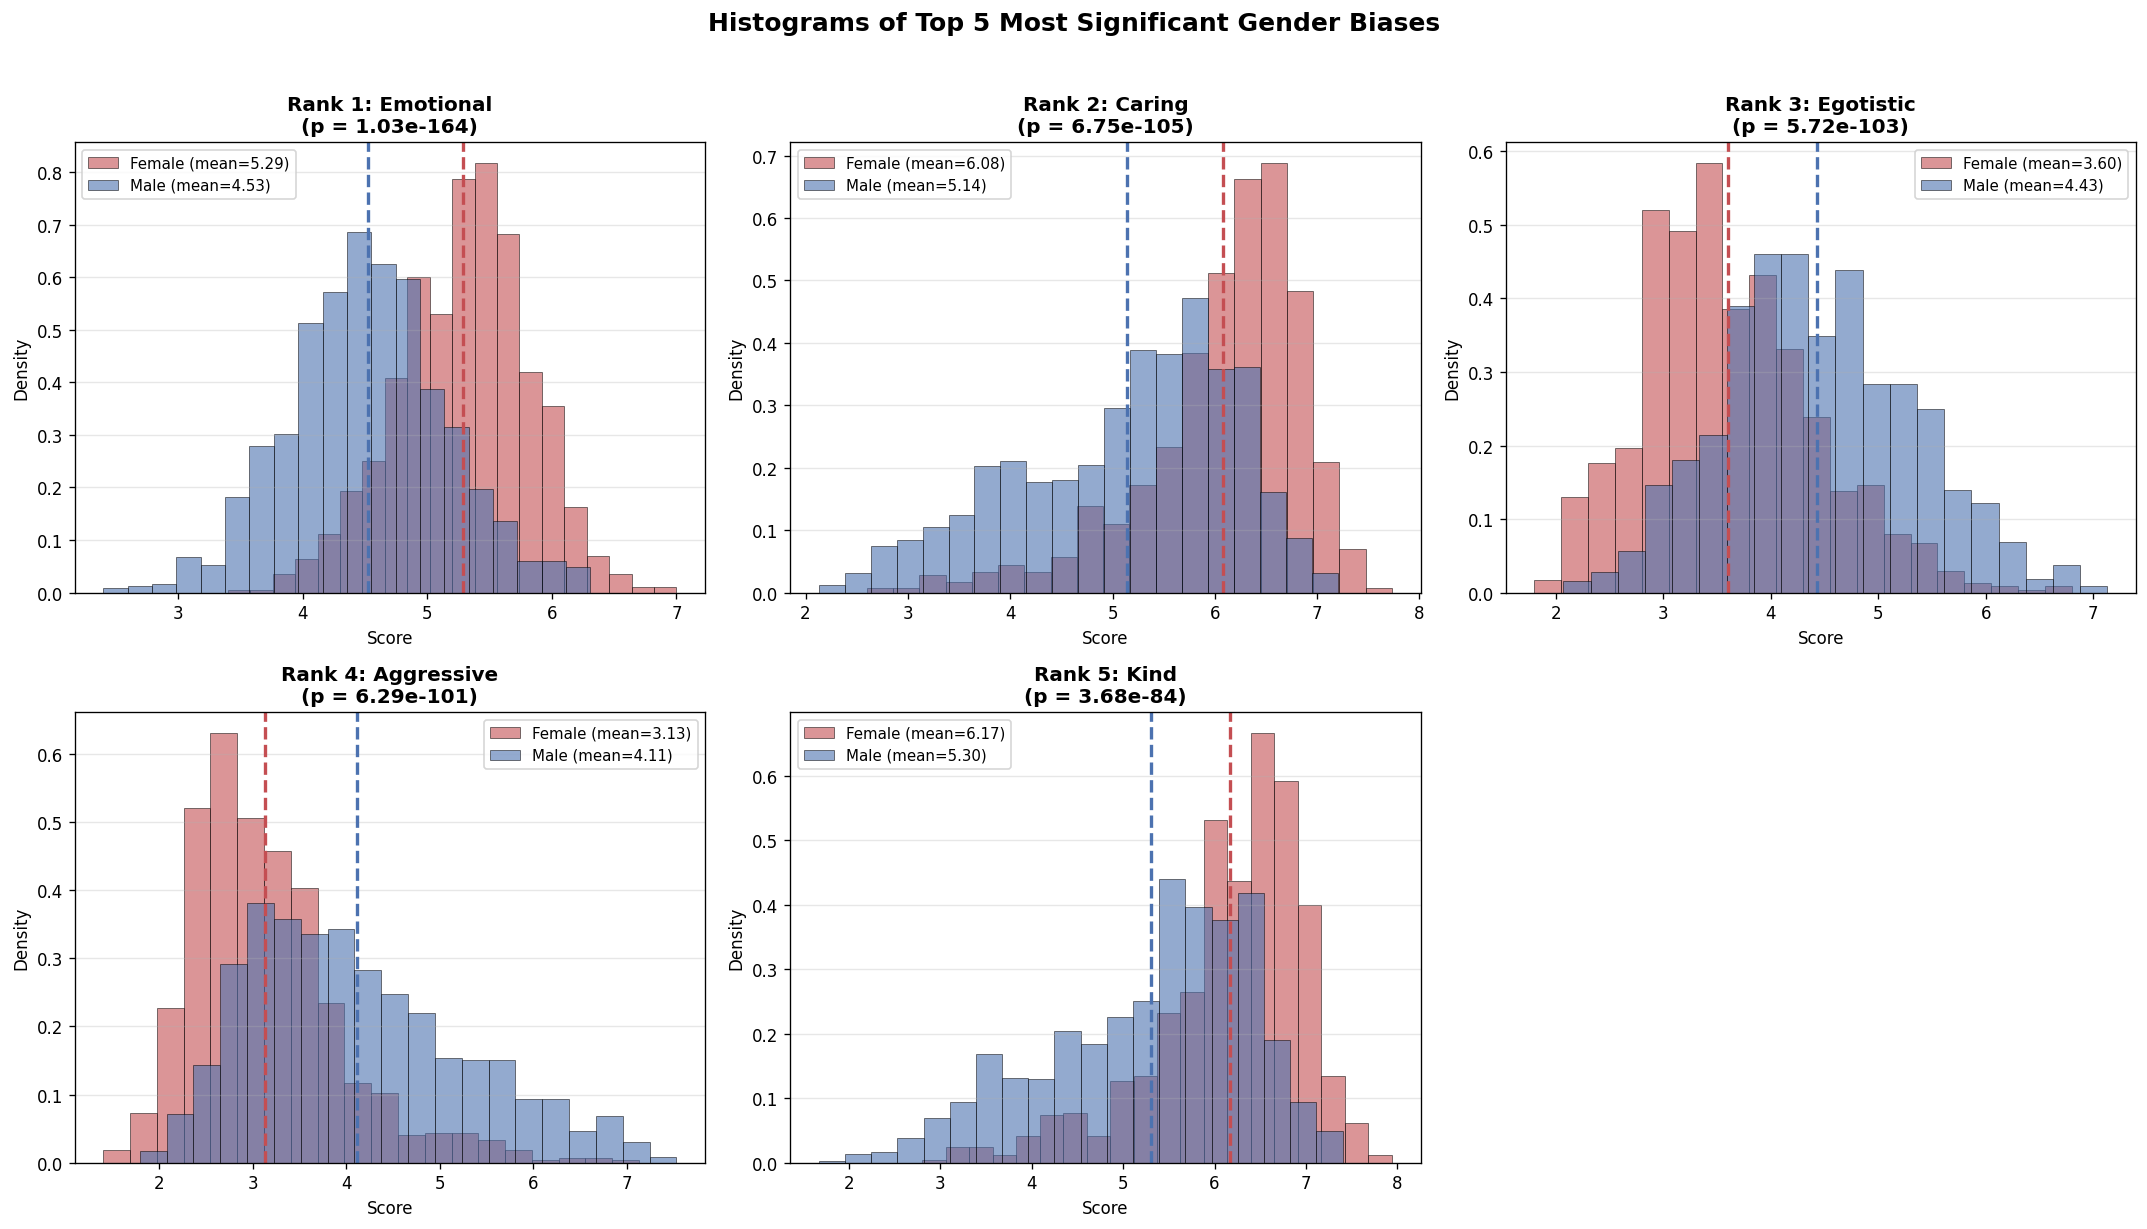

In [ ]:
# ============================================================
# Plot histograms for the top 5 most significant biases
# ============================================================

# The top 5 biases are all Gender-related:
# 1. Emotional, 2. Caring, 3. Egotistic, 4. Aggressive, 5. Kind
top5_traits = ['Emotional', 'Caring', 'Egotistic', 'Aggressive', 'Kind']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, trait in enumerate(top5_traits):
    ax = axes[i]

    # Get data for each gender group
    female_data = df[df['Gender'] == 0][trait].dropna()
    male_data = df[df['Gender'] == 1][trait].dropna()

    # Plot overlapping histograms with transparency
    ax.hist(female_data, bins=20, alpha=0.6, label=f'Female (mean={female_data.mean():.2f})',
            color='#C44E52', edgecolor='black', linewidth=0.5, density=True)
    ax.hist(male_data, bins=20, alpha=0.6, label=f'Male (mean={male_data.mean():.2f})',
            color='#4C72B0', edgecolor='black', linewidth=0.5, density=True)

    # Add vertical lines at the means
    ax.axvline(female_data.mean(), color='#C44E52', linestyle='--', linewidth=2)
    ax.axvline(male_data.mean(), color='#4C72B0', linestyle='--', linewidth=2)

    # Retrieve the p-value for annotation
    p_val = top5.iloc[i]['p-value']
    ax.set_title(f'Rank {i+1}: {trait}\n(p = {p_val:.2e})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Hide the 6th subplot (unused)
axes[5].set_visible(False)

plt.suptitle('Histograms of Top 5 Most Significant Gender Biases', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Adverse Impact Analysis

For this section, we will apply the four-fifths rule to the `Qualified` column (last column in data.csv), which contains binary predictions (0 = not qualified, 1 = qualified) from a classifier determining job eligibility.

In [ ]:
# ============================================================
# Four-Fifths Rule Analysis
# ============================================================

# compute selection rates by Gender
print("=" * 80)
print("FOUR-FIFTHS RULE ANALYSIS: GENDER")
print("=" * 80)

gender_groups = {0: 'Female', 1: 'Male'}
gender_selection = {}

for code_val, label in gender_groups.items():
    group = df[df['Gender'] == code_val]
    total = len(group)
    selected = group['Qualified'].sum()
    rate = selected / total
    gender_selection[label] = {'Total': total, 'Selected': selected, 'Rate': rate}
    print(f"  {label}: {selected}/{total} selected = {rate:.4f} ({rate*100:.2f}%)")

# Identify the group with the highest selection rate
max_gender_group = max(gender_selection, key=lambda k: gender_selection[k]['Rate'])
max_gender_rate = gender_selection[max_gender_group]['Rate']
print(f"\n  Highest selection rate: {max_gender_group} ({max_gender_rate:.4f})")
print(f"  Four-fifths threshold: {0.8 * max_gender_rate:.4f} ({0.8 * max_gender_rate * 100:.2f}%)")

# Check each group against the four-fifths rule
print(f"\n  Adverse Impact Check:")
for label, info in gender_selection.items():
    ratio = info['Rate'] / max_gender_rate
    adverse = ratio < 0.8
    status = "ADVERSE IMPACT DETECTED" if adverse else "No adverse impact"
    print(f"    {label}: ratio = {ratio:.4f} ({ratio*100:.2f}%) -> {status}")

FOUR-FIFTHS RULE ANALYSIS: GENDER
  Female: 113/953 selected = 0.1186 (11.86%)
  Male: 265/1269 selected = 0.2088 (20.88%)

  Highest selection rate: Male (0.2088)
  Four-fifths threshold: 0.1671 (16.71%)

  Adverse Impact Check:
    Female: ratio = 0.5678 (56.78%) -> ADVERSE IMPACT DETECTED
    Male: ratio = 1.0000 (100.00%) -> No adverse impact


In [14]:
# compute selection rates by race (White, Black, East Asian)
print("=" * 80)
print("FOUR-FIFTHS RULE ANALYSIS: RACE (White, Black, East Asian)")
print("=" * 80)

race_groups = {1: 'White', 2: 'Black', 3: 'East Asian'}
race_selection = {}

for code_val, label in race_groups.items():
    group = df[df['Race'] == code_val]
    total = len(group)
    selected = group['Qualified'].sum()
    rate = selected / total
    race_selection[label] = {'Total': total, 'Selected': selected, 'Rate': rate}
    print(f"  {label}: {selected}/{total} selected = {rate:.4f} ({rate*100:.2f}%)")

# Identify the group with the highest selection rate
max_race_group = max(race_selection, key=lambda k: race_selection[k]['Rate'])
max_race_rate = race_selection[max_race_group]['Rate']
print(f"\n  Highest selection rate: {max_race_group} ({max_race_rate:.4f})")
print(f"  Four-fifths threshold: {0.8 * max_race_rate:.4f} ({0.8 * max_race_rate * 100:.2f}%)")

# Check each group against the four-fifths rule
print(f"\n  Adverse Impact Check:")
for label, info in race_selection.items():
    ratio = info['Rate'] / max_race_rate
    adverse = ratio < 0.8
    status = "ADVERSE IMPACT DETECTED" if adverse else "No adverse impact"
    print(f"    {label}: ratio = {ratio:.4f} ({ratio*100:.2f}%) -> {status}")

FOUR-FIFTHS RULE ANALYSIS: RACE (White, Black, East Asian)
  White: 336/1836 selected = 0.1830 (18.30%)
  Black: 27/220 selected = 0.1227 (12.27%)
  East Asian: 11/63 selected = 0.1746 (17.46%)

  Highest selection rate: White (0.1830)
  Four-fifths threshold: 0.1464 (14.64%)

  Adverse Impact Check:
    White: ratio = 1.0000 (100.00%) -> No adverse impact
    Black: ratio = 0.6706 (67.06%) -> ADVERSE IMPACT DETECTED
    East Asian: ratio = 0.9541 (95.41%) -> No adverse impact


In [15]:
# comprehensive analysis across ALL race and gender groups
print("=" * 80)
print("FOUR-FIFTHS RULE ANALYSIS: ALL GROUPS COMBINED")
print("=" * 80)

all_selection = {}

# Add gender groups
for code_val, label in gender_groups.items():
    group = df[df['Gender'] == code_val]
    total = len(group)
    selected = int(group['Qualified'].sum())
    rate = selected / total
    all_selection[f"Gender: {label}"] = {'Total': total, 'Selected': selected, 'Rate': rate}

# Add race groups (focused three)
for code_val, label in race_groups.items():
    group = df[df['Race'] == code_val]
    total = len(group)
    selected = int(group['Qualified'].sum())
    rate = selected / total
    all_selection[f"Race: {label}"] = {'Total': total, 'Selected': selected, 'Rate': rate}

# Find the overall highest selection rate
max_group = max(all_selection, key=lambda k: all_selection[k]['Rate'])
max_rate = all_selection[max_group]['Rate']

print(f"\n{'Group':<25} {'Selected':>10} {'Total':>8} {'Rate':>10} {'Ratio':>10} {'Adverse Impact?':>18}")
print("-" * 85)

for group, info in all_selection.items():
    ratio = info['Rate'] / max_rate
    adverse = "YES" if ratio < 0.8 else "No"
    marker = " <--" if ratio < 0.8 else ""
    print(f"{group:<25} {info['Selected']:>10} {info['Total']:>8} {info['Rate']:>10.4f} {ratio:>10.4f} {adverse:>18}{marker}")

print(f"\nReference group (highest rate): {max_group} (rate = {max_rate:.4f})")
print(f"Four-fifths threshold: {0.8 * max_rate:.4f}")

FOUR-FIFTHS RULE ANALYSIS: ALL GROUPS COMBINED

Group                       Selected    Total       Rate      Ratio    Adverse Impact?
-------------------------------------------------------------------------------------
Gender: Female                   113      953     0.1186     0.5678                YES <--
Gender: Male                     265     1269     0.2088     1.0000                 No
Race: White                      336     1836     0.1830     0.8764                 No
Race: Black                       27      220     0.1227     0.5877                YES <--
Race: East Asian                  11       63     0.1746     0.8361                 No

Reference group (highest rate): Gender: Male (rate = 0.2088)
Four-fifths threshold: 0.1671


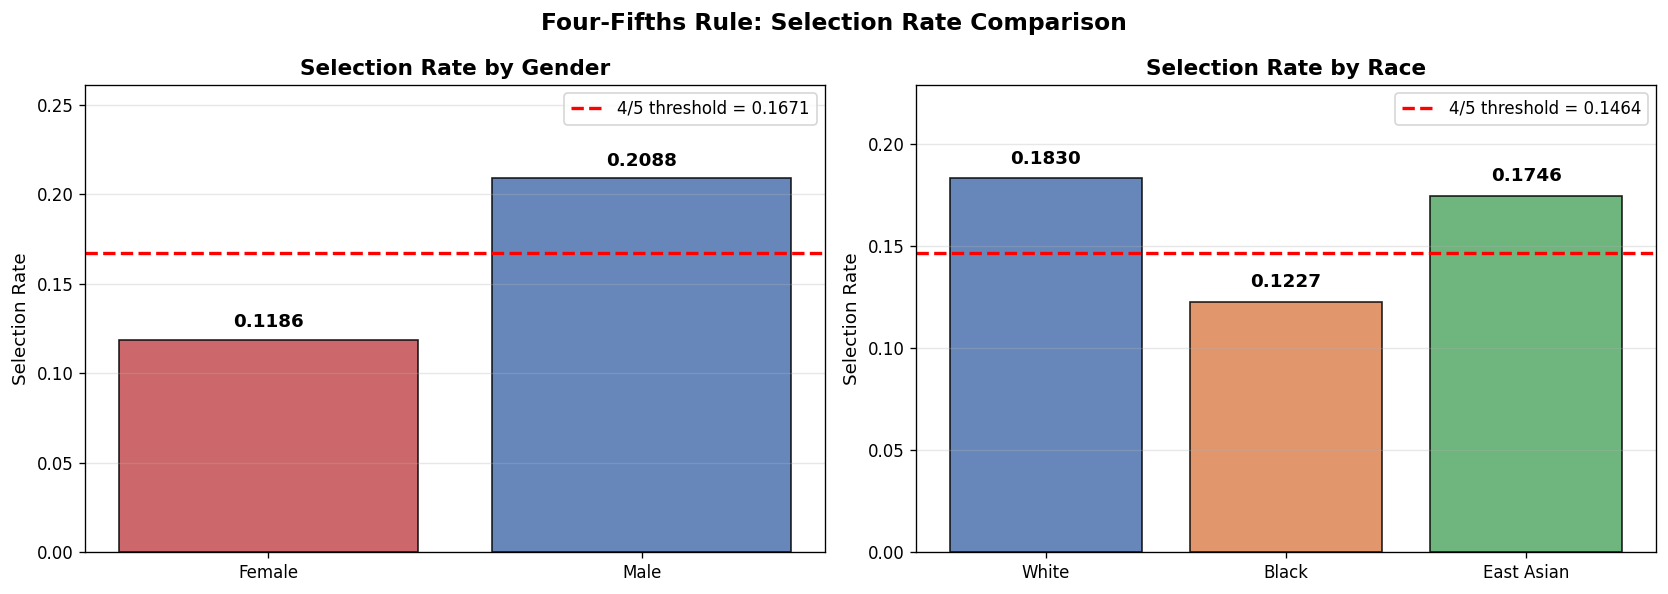

In [16]:
# Visualize selection rates with the four-fifths threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender subplot
ax = axes[0]
gender_labels = list(gender_selection.keys())
gender_rates = [gender_selection[g]['Rate'] for g in gender_labels]
colors_g = ['#C44E52' if g == 'Female' else '#4C72B0' for g in gender_labels]

bars = ax.bar(gender_labels, gender_rates, color=colors_g, alpha=0.85, edgecolor='black')
threshold_g = 0.8 * max(gender_rates)
ax.axhline(y=threshold_g, color='red', linestyle='--', linewidth=2, label=f'4/5 threshold = {threshold_g:.4f}')

# Annotate bars with rates
for bar, rate in zip(bars, gender_rates):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{rate:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Selection Rate by Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Selection Rate', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, max(gender_rates) * 1.25)
ax.grid(axis='y', alpha=0.3)

# Race subplot
ax = axes[1]
race_labels = list(race_selection.keys())
race_rates = [race_selection[r]['Rate'] for r in race_labels]
colors_r = ['#4C72B0', '#DD8452', '#55A868']

bars = ax.bar(race_labels, race_rates, color=colors_r, alpha=0.85, edgecolor='black')
threshold_r = 0.8 * max(race_rates)
ax.axhline(y=threshold_r, color='red', linestyle='--', linewidth=2, label=f'4/5 threshold = {threshold_r:.4f}')

# Annotate bars with rates
for bar, rate in zip(bars, race_rates):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{rate:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Selection Rate by Race', fontsize=13, fontweight='bold')
ax.set_ylabel('Selection Rate', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, max(race_rates) * 1.25)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Four-Fifths Rule: Selection Rate Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()